<a href="https://colab.research.google.com/github/RehhagagelWijanarko/Telco-Customer-Churn/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preparation

In [21]:
import numpy as np
import pandas as pd

In [22]:
!pip install kaggle

In [23]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [24]:
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)


In [25]:
!unzip telco-customer-churn.zip

Archive:  telco-customer-churn.zip
replace WA_Fn-UseC_-Telco-Customer-Churn.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [8]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# 1. Filter kolom yang bertipe 'object'
object_cols = df.select_dtypes(include=['object']).columns

print(f"Daftar kolom bertipe objek: {list(object_cols)}\n")

# 2. Loop untuk melihat nilai unik di setiap kolom
for col in object_cols:
    unique_values = df[col].unique()
    num_unique = df[col].nunique()
    print(f"Kolom: {col}")
    print(f"Jumlah kategori unik: {num_unique}")
    print(f"Nilai unik: {unique_values}")
    print("-" * 30)

Daftar kolom bertipe objek: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Kolom: customerID
Jumlah kategori unik: 7043
Nilai unik: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
------------------------------
Kolom: gender
Jumlah kategori unik: 2
Nilai unik: ['Female' 'Male']
------------------------------
Kolom: Partner
Jumlah kategori unik: 2
Nilai unik: ['Yes' 'No']
------------------------------
Kolom: Dependents
Jumlah kategori unik: 2
Nilai unik: ['No' 'Yes']
------------------------------
Kolom: PhoneService
Jumlah kategori unik: 2
Nilai unik: ['No' 'Yes']
------------------------------
Kolom: MultipleLines
Jumlah kategori unik: 3
Nilai unik: ['No phone service' 'No' 'Yes']
------------------------------
Kolom: 

In [12]:
print("Jumlah Missing Values pada Setiap Kolom")
print(df.isnull().sum())

Jumlah Missing Values pada Setiap Kolom
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [13]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

In [14]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
# CustomerID tidak diperlukan karena tidak akan berpengaruh terhadap churn dan hanya sebagai variabel pelengkap, penanda objek atau baris saja.
df.drop('customerID', axis=1, inplace=True)

In [17]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [18]:
# Khusus Gender
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

In [19]:
nominal_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df = pd.get_dummies(data=df, columns=nominal_cols, drop_first=True, dtype=int)

In [26]:
# Cek hasil akhir
print("Tipe data setelah encoding:")
print(df.dtypes)
print("\n5 Baris pertama data:")
display(df.head())

Tipe data setelah encoding:
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                     

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


# Statistika Deskriptif

In [30]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
MonthlyCharges,0
TotalCharges,11
Churn,0


In [32]:
df = df.dropna()

In [33]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
MonthlyCharges,0
TotalCharges,0
Churn,0


In [34]:
# Statistika deskriptif untuk kolom numerik asli
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print("Statistika Deskriptif Variabel Numerik:")
display(df[num_cols].describe())


Statistika Deskriptif Variabel Numerik:


,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [35]:
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges','Churn']
print("Korelasi Variabel Numerik dengan Variabel Respon (Churn)")
display(df[corr_cols].corr())

Korelasi Variabel Numerik dengan Variabel Respon (Churn)


,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.354049,0.192858,-0.199484,1.000000


Proporsi Churn (Target):
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


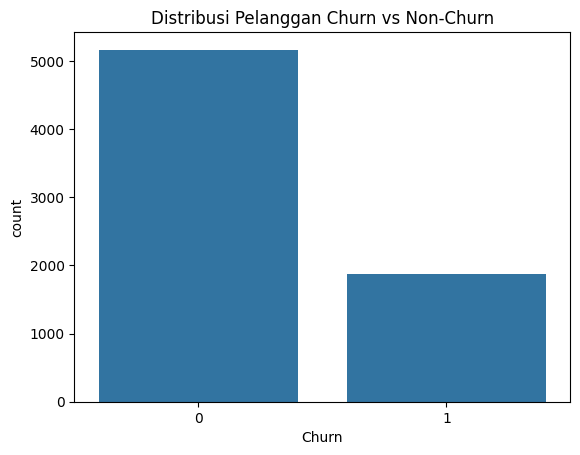

In [36]:
# Melihat proporsi target variable (Churn) - Sangat Penting!
print("Proporsi Churn (Target):")
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualisasi distribusi Churn
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title('Distribusi Pelanggan Churn vs Non-Churn')
plt.show()

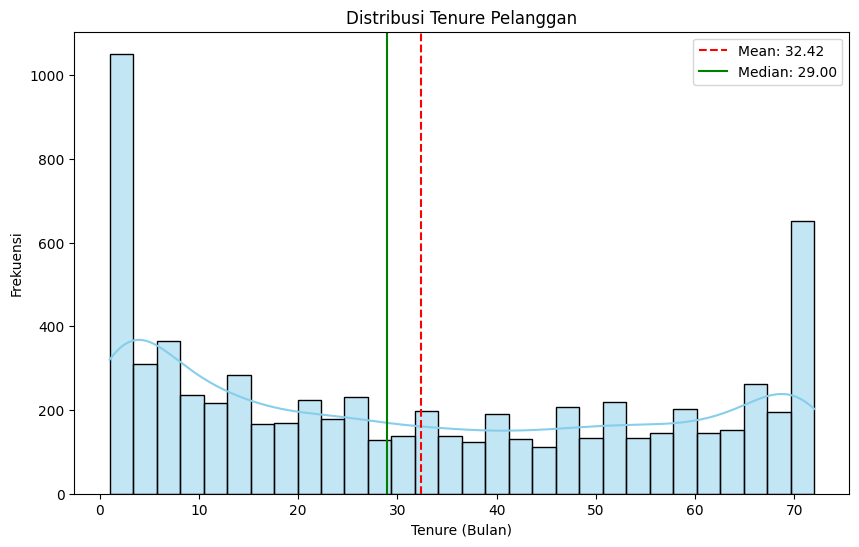

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram untuk kolom 'tenure'
plt.figure(figsize=(10, 6))
sns.histplot(df['tenure'], kde=True, color='skyblue', bins=30)

# Menambahkan detail statistik (Sangat disukai rekruter!)
plt.axvline(df['tenure'].mean(), color='red', linestyle='--', label=f'Mean: {df["tenure"].mean():.2f}')
plt.axvline(df['tenure'].median(), color='green', linestyle='-', label=f'Median: {df["tenure"].median():.2f}')

plt.title('Distribusi Tenure Pelanggan')
plt.xlabel('Tenure (Bulan)')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

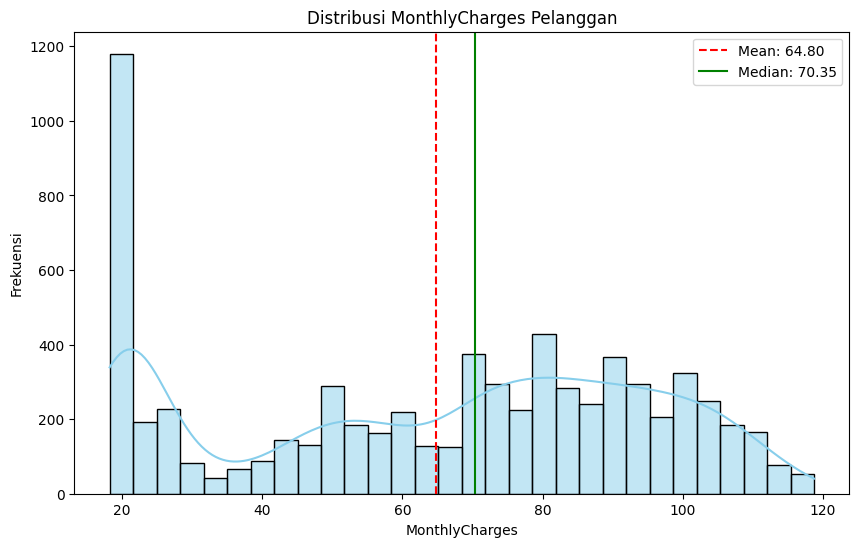

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram untuk kolom 'tenure'
plt.figure(figsize=(10, 6))
sns.histplot(df['MonthlyCharges'], kde=True, color='skyblue', bins=30)

# Menambahkan detail statistik (Sangat disukai rekruter!)
plt.axvline(df['MonthlyCharges'].mean(), color='red', linestyle='--', label=f'Mean: {df['MonthlyCharges'].mean():.2f}')
plt.axvline(df['MonthlyCharges'].median(), color='green', linestyle='-', label=f'Median: {df['MonthlyCharges'].median():.2f}')

plt.title('Distribusi MonthlyCharges Pelanggan')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

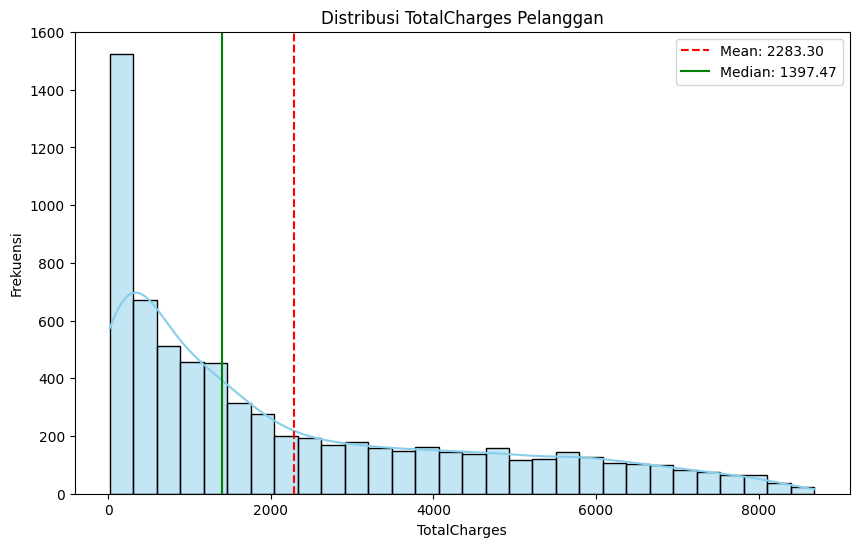

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram untuk kolom 'tenure'
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalCharges'], kde=True, color='skyblue', bins=30)

# Menambahkan detail statistik (Sangat disukai rekruter!)
plt.axvline(df['TotalCharges'].mean(), color='red', linestyle='--', label=f'Mean: {df['TotalCharges'].mean():.2f}')
plt.axvline(df['TotalCharges'].median(), color='green', linestyle='-', label=f'Median: {df['TotalCharges'].median():.2f}')

plt.title('Distribusi TotalCharges Pelanggan')
plt.xlabel('TotalCharges')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

# Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Pisahkan fitur (X) dan target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

In [52]:
# 2. Split data (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [54]:
# 2. Fit model (gunakan parameter sederhana dulu)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [55]:
# 3. Ambil feature importance
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

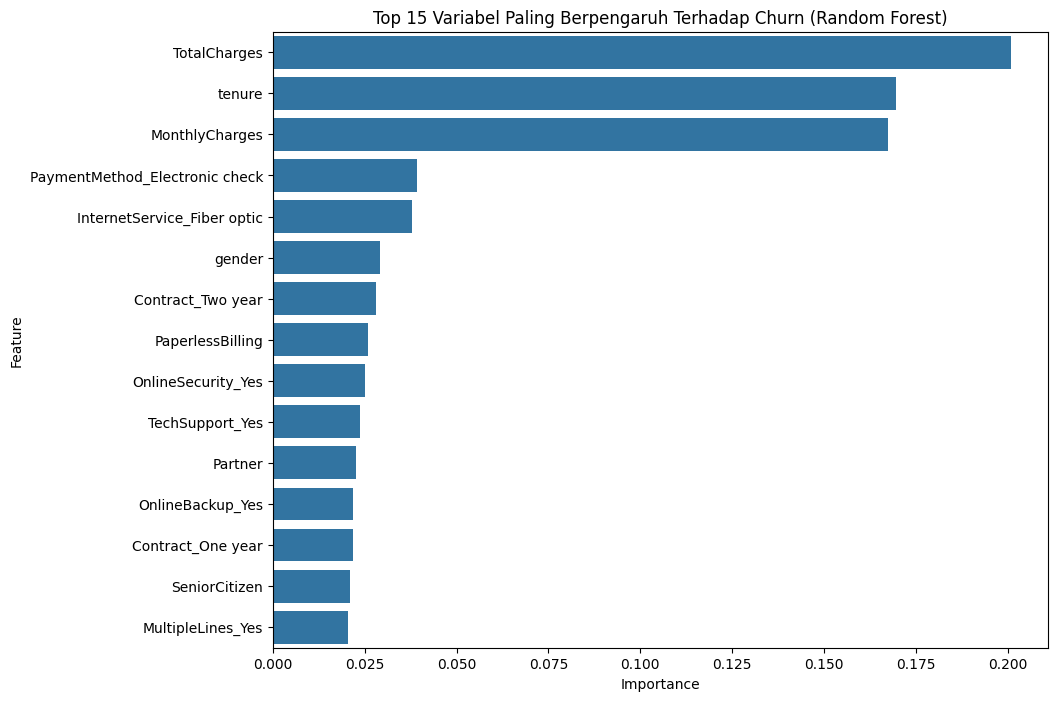

In [56]:
# 4. Visualisasi
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Variabel Paling Berpengaruh Terhadap Churn (Random Forest)')
plt.show()

In [58]:
# 4. Prediksi pada data uji
y_pred = rf.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix
# Mendapatkan nilai metrik secara individu
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {acc:.2f}")
print(f"Precision : {prec:.2f}")
print(f"Recall    : {rec:.2f}")
print(f"F1-Score  : {f1:.2f}")

# Atau cara yang lebih lengkap untuk Portofolio:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy  : 0.79
Precision : 0.63
Recall    : 0.50
F1-Score  : 0.56

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



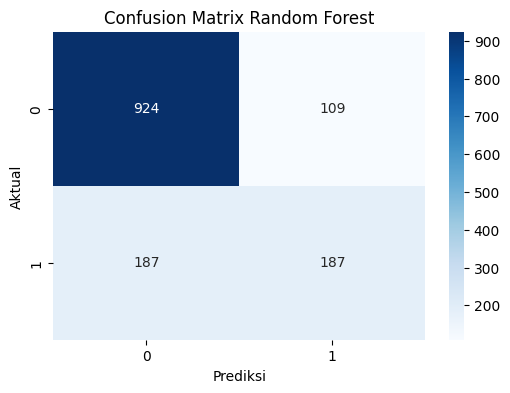

In [61]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()